# RNN Exercises
For these exercises we're using data from the Federal Reserve Economic Database (FRED) concerning Electricity and Gas Utilities Production from January 1992 to January 2019 (325 records).

Data source: https://fred.stlouisfed.org/series/IPG2211A2N

In the exercises below you'll be asked to do the following:
* Perform standard imports, load & plot the dataset (code provided)
* Prepare data for an LSTM model
* Define the LSTM model, loss and optimization functions
* Train the model
* Evaluate the model on test data
* OPTIONAL: Plot the results

<div class="alert alert-danger" style="margin: 10px"><strong>IMPORTANT NOTE!</strong> Make sure you don't run the cells directly above the example output shown, <br>otherwise you will end up writing over the example output!</div>

## Perform standard imports, load and plot the dataset
Run the cells below to load the libraries needed for this exercise and the Energy Production dataset, and to plot the data.

In [2]:
#Name: Joel John Jobinse
#Register No: 212223240062
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

df = pd.read_csv('IPG2211A2N.csv',index_col=0,parse_dates=True)
df.dropna(inplace=True)
print(len(df))
df.head()

1048


,IPG2211A2N
observation_date,
1939-01-01,3.3336
1939-02-01,3.3591
1939-03-01,3.4354
1939-04-01,3.4608
1939-05-01,3.4608


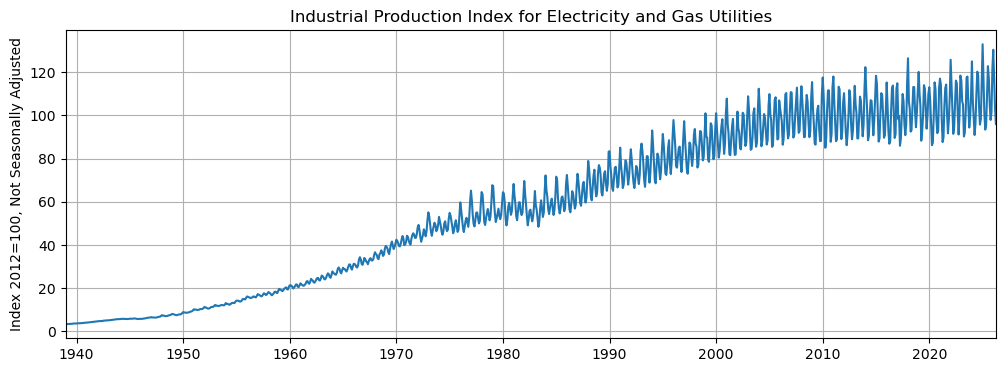

In [3]:
plt.figure(figsize=(12,4))
plt.title('Industrial Production Index for Electricity and Gas Utilities')
plt.ylabel('Index 2012=100, Not Seasonally Adjusted')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(df['IPG2211A2N'])
plt.show()

# Prepare the data
For the first set of exercises we'll
* divide the data into train and test sets
* normalize the training set
* prepare windowed seq/label tuples for an LSTM model

## 1. Divide the data into train and test sets
Working with a window_size of 12, divide the dataset into a sequence of 313 training records (including the window), and a test set of 12 records.

In [6]:
y = df['IPG2211A2N'].values.astype(float)

test_size = 12
window_size = 12

train_set = y[:-test_size]
test_set = y[-test_size:]

In [7]:
print(f'Train: {len(train_set)}')
print(f'Test:  {len(test_set)}')

Train: 1036
Test:  12


In [3]:
# DON'T WRITE HERE

Train: 313
Test:  12


## 2. Normalize the training set
Feature scale the training set to fit within the range [-1,1].

In [8]:
scaler = MinMaxScaler(feature_range=(-1, 1))

scaler.fit(train_set.reshape(-1,1))

train_norm = scaler.transform(train_set.reshape(-1,1))

In [9]:
print(f'First item, original: {train_set[0]}')
print(f'First item, scaled:  {train_norm[0]}')

First item, original: 3.3336
First item, scaled:  [-1.]


In [4]:
# DON'T WRITE HERE

First item, original: 85.556
First item, scaled: [-0.4091274]


## 3. Prepare data for LSTM
Prepare the list of windowed sequence/label tuples to be fed into an LSTM model.

In [10]:
train_norm = torch.FloatTensor(train_norm).view(-1)

def input_data(seq,ws):
    out = []
    L = len(seq)
    for i in range(L-ws):
        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1]
        out.append((window,label))
    return out

In [11]:
train_data = input_data(train_norm, window_size)

In [12]:
print(f'Train_data: {len(train_data)}')

Train_data: 1024


In [6]:
# DON'T WRITE HERE

Train_data: 301


## 4. Define the model
Design a model that has a (1,64) LSTM layer and a (64,1) fully-connected linear layer. Be sure to initialize $h_0$ and $c_0$, and return only the last predicted value.

In [13]:
class LSTMnetwork(nn.Module):

    def __init__(self):

        super().__init__()

        self.hidden_size = 64

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=self.hidden_size
        )

        self.linear = nn.Linear(
            self.hidden_size,
            1
        )

        self.hidden = (
            torch.zeros(1,1,self.hidden_size),
            torch.zeros(1,1,self.hidden_size)
        )

    def forward(self,seq):

        lstm_out, self.hidden = self.lstm(
            seq.view(len(seq),1,-1),
            self.hidden
        )

        pred = self.linear(
            lstm_out.view(len(seq),self.hidden_size)
        )

        return pred[-1]

In [14]:
# Run the code below to check your results:
torch.manual_seed(101)
model = LSTMnetwork()
model

LSTMnetwork(
  (lstm): LSTM(1, 64)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)

In [7]:
# DON'T WRITE HERE

LSTMnetwork(
  (lstm): LSTM(1, 64)
  (linear): Linear(in_features=64, out_features=1, bias=True)
)

## 5. Define loss and optimization functions
Define a loss function called "criterion" and an optimizer called "optimizer".<br>
You can use any functions you want, although we used MSELoss and Adam (learning rate of 0.001) respectively.

In [15]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [8]:
# DON'T WRITE HERE

### 6. Train the model
Don't worry about tracking loss values, displaying results, or validating the test set. Just train the model through 50 epochs. We'll evaluate the trained model in the next step.<br>
OPTIONAL: print something after each epoch to indicate training progress.

In [16]:
epochs = 50

for i in range(epochs):

    for seq,y_train in train_data:

        optimizer.zero_grad()

        model.hidden = (
            torch.zeros(1,1,model.hidden_size),
            torch.zeros(1,1,model.hidden_size)
        )

        y_pred = model(seq)

        loss = criterion(
            y_pred,
            y_train
        )

        loss.backward()

        optimizer.step()

    print(
        f'Epoch: {i+1} Loss: {loss.item()}'
    )

Epoch: 1 Loss: 0.06953678280115128
Epoch: 2 Loss: 0.04734111577272415
Epoch: 3 Loss: 8.143515879055485e-05
Epoch: 4 Loss: 0.0006651612929999828
Epoch: 5 Loss: 0.0005820764927193522
Epoch: 6 Loss: 0.0004784293123520911
Epoch: 7 Loss: 0.0003118026943411678
Epoch: 8 Loss: 0.0002964757150039077
Epoch: 9 Loss: 0.0003388588665984571
Epoch: 10 Loss: 0.00037654043990187347
Epoch: 11 Loss: 0.00039180784369818866
Epoch: 12 Loss: 0.00038994476199150085
Epoch: 13 Loss: 0.00041276426054537296
Epoch: 14 Loss: 0.0004630034673027694
Epoch: 15 Loss: 0.000468214915599674
Epoch: 16 Loss: 0.0005297131719999015
Epoch: 17 Loss: 0.0005257095326669514
Epoch: 18 Loss: 0.0005411009769886732
Epoch: 19 Loss: 0.0005007907748222351
Epoch: 20 Loss: 0.00048347757547162473
Epoch: 21 Loss: 0.00044996460201218724
Epoch: 22 Loss: 0.0004328666836954653
Epoch: 23 Loss: 0.0004226791497785598
Epoch: 24 Loss: 0.0004212111234664917
Epoch: 25 Loss: 0.00043543626088649035
Epoch: 26 Loss: 0.0004231289785820991
Epoch: 27 Loss: 0.0

In [9]:
# DON'T WRITE HERE

1 of 50 epochs completed
2 of 50 epochs completed
3 of 50 epochs completed
4 of 50 epochs completed
5 of 50 epochs completed
6 of 50 epochs completed
7 of 50 epochs completed
8 of 50 epochs completed
9 of 50 epochs completed
10 of 50 epochs completed
11 of 50 epochs completed
12 of 50 epochs completed
13 of 50 epochs completed
14 of 50 epochs completed
15 of 50 epochs completed
16 of 50 epochs completed
17 of 50 epochs completed
18 of 50 epochs completed
19 of 50 epochs completed
20 of 50 epochs completed
21 of 50 epochs completed
22 of 50 epochs completed
23 of 50 epochs completed
24 of 50 epochs completed
25 of 50 epochs completed
26 of 50 epochs completed
27 of 50 epochs completed
28 of 50 epochs completed
29 of 50 epochs completed
30 of 50 epochs completed
31 of 50 epochs completed
32 of 50 epochs completed
33 of 50 epochs completed
34 of 50 epochs completed
35 of 50 epochs completed
36 of 50 epochs completed
37 of 50 epochs completed
38 of 50 epochs completed
39 of 50 epochs compl

### 9. Evaluate the model using the test set
Be sure to re-initialize the hidden parameters $h_0$ and $c_0$ before running the model.

In [17]:
future = 12

preds = train_norm[-window_size:].tolist()

model.eval()

for i in range(future):

    seq = torch.FloatTensor(
        preds[-window_size:]
    )

    with torch.no_grad():

        model.hidden = (
            torch.zeros(1,1,model.hidden_size),
            torch.zeros(1,1,model.hidden_size)
        )

        preds.append(
            model(seq).item()
        )

In [18]:
# Run the code below to check your results:
preds[window_size:]

[0.44283998012542725,
 0.6506097912788391,
 0.8263996839523315,
 0.7670780420303345,
 0.5606584548950195,
 0.4151085913181305,
 0.4892503619194031,
 0.7200990915298462,
 0.8688689470291138,
 0.721013069152832,
 0.550999641418457,
 0.3835236430168152]

In [10]:
# DON'T WRITE HERE

[0.25382155179977417,
 -0.0027704648673534393,
 -0.343053936958313,
 -0.21152164041996002,
 0.23945370316505432,
 0.4895053505897522,
 0.24688751995563507,
 -0.08669154345989227,
 -0.25793153047561646,
 0.022461334243416786,
 0.5438402891159058,
 0.6108715534210205]

## 10. Inverse transform the predicted values
Rescale the predicted values up to the original test set range.

In [19]:
true_predictions = scaler.inverse_transform(
    np.array(
        preds[window_size:]
    ).reshape(-1,1)
)

In [20]:
# Run the code below to check your results:
true_predictions

array([[ 96.7643422 ],
       [110.21842438],
       [121.60165493],
       [117.76029684],
       [104.39364808],
       [ 94.96860305],
       [ 99.76963487],
       [114.71818665],
       [124.35174145],
       [114.77737104],
       [103.76819403],
       [ 92.92332762]])

In [11]:
# DON'T WRITE HERE

array([[105.95129313],
       [ 98.05736803],
       [ 87.58871716],
       [ 91.63524249],
       [105.50927345],
       [113.20198736],
       [105.73797111],
       [ 95.47557801],
       [ 90.20746543],
       [ 98.83361172],
       [114.87357457],
       [116.93575791]])

## BONUS EXERCISE: Plot the result
Plot the true_predictions values together with the original data. Remember to create a range of datetime values for the predicted data.

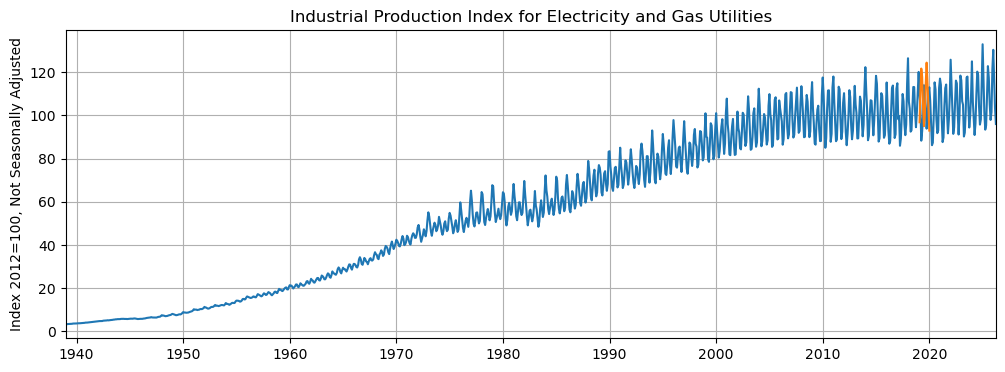

In [21]:
x = np.arange(
    len(df),
    len(df)+future
)

plt.figure(figsize=(12,4))

plt.title(
'Industrial Production Index for Electricity and Gas Utilities'
)

plt.ylabel(
'Index 2012=100, Not Seasonally Adjusted'
)

plt.grid(True)

plt.autoscale(axis='x',tight=True)

plt.plot(df['IPG2211A2N'])

plt.plot(
pd.date_range(
start='2019-02-01',
periods=future,
freq='MS'
),
true_predictions
)

plt.show()

In [ ]:
plt.figure(figsize=(12,4))

plt.title(
'Industrial Production Index for Electricity and Gas Utilities'
)

plt.ylabel(
'Index 2012=100, Not Seasonally Adjusted'
)

plt.grid(True)

plt.plot(df['IPG2211A2N'])

plt.plot(
pd.date_range(
start='2019-02-01',
periods=future,
freq='MS'
),
true_predictions
)

plt.xlim(
'2017-01-01',
'2020-01-01'
)

plt.show()

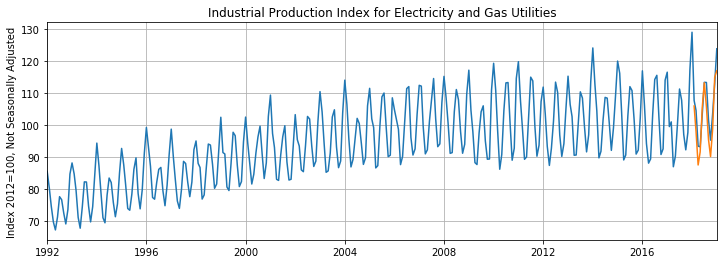

In [12]:
# DON'T WRITE HERE

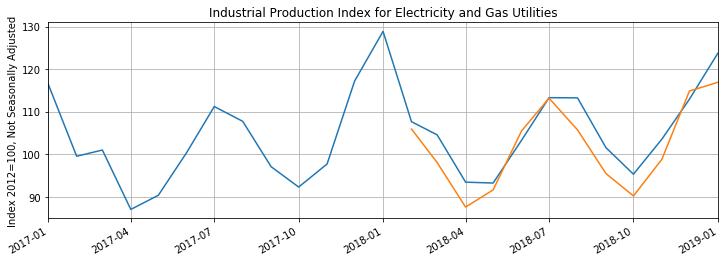

In [13]:
# DON'T WRITE HERE

## Great job!